In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("income.csv")

In [3]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


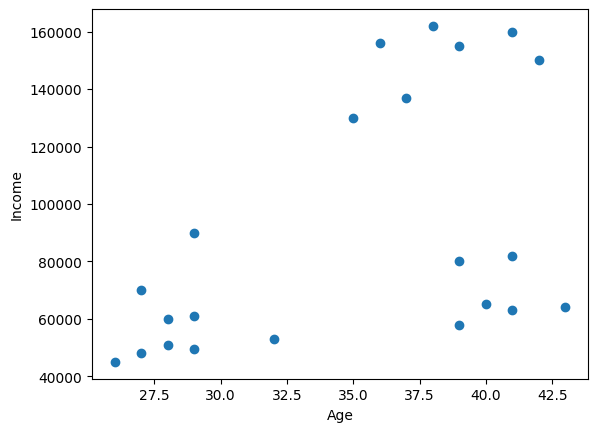

In [5]:
plt.scatter(df['Age'] , df['Income($)'])
plt.xlabel('Age')
plt.ylabel("Income")d
plt.show()

In [6]:
from sklearn.cluster import KMeans

In [7]:
km = KMeans(n_clusters = 3)

In [8]:
y_pred = km.fit_predict(df[['Age' ,'Income($)']])

In [9]:
y_pred

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0])

In [10]:
df['Cluster'] = y_pred

In [11]:
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [12]:
print(km.cluster_centers_)

[[3.29090909e+01 5.61363636e+04]
 [3.82857143e+01 1.50000000e+05]
 [3.40000000e+01 8.05000000e+04]]


In [13]:
x = km.cluster_centers_[:,0]
y = km.cluster_centers_[: , 1]

In [15]:
df1 = df[df.Cluster == 0]
df2 = df[df.Cluster == 1]
df3 = df[df.Cluster == 2]

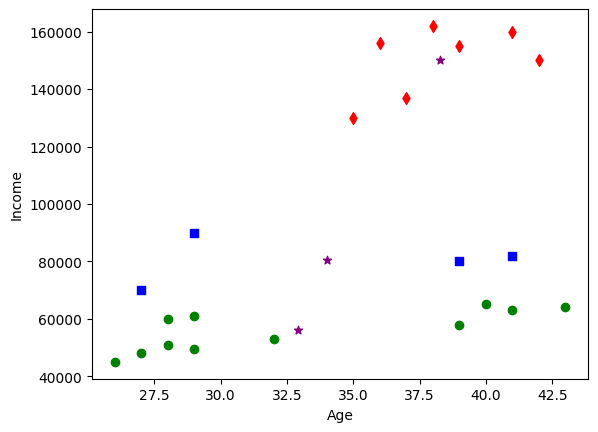

In [16]:
# Plot each cluster
plt.scatter(df1.Age, df1['Income($)'], color='green', marker='o')
plt.scatter(df2.Age, df2['Income($)'], color='red',  marker='d')
plt.scatter(df3.Age, df3['Income($)'], color='blue',  marker='s')

plt.scatter(x,y,color = 'purple' , marker = '*' , label = 'centroid')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()


In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
scaler = MinMaxScaler()

In [22]:
scaler.fit(df[['Income($)']])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [25]:
df['Income($)'] = scaler.transform(df[['Income($)']])

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Income($)
Feature names seen at fit time, yet now missing:
- Age


In [24]:
scaler.fit(df[['Age']])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [26]:
df['Age'] = scaler.transform(df[['Age']])

In [27]:
df.head()

,Name,Age,Income($),Cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [28]:
km = KMeans(n_clusters = 3)

In [29]:
y_pred = km.fit_predict(df[['Age' ,'Income($)']])

In [30]:
y_pred

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2])

In [31]:
df['Cluster'] = y_pred

In [32]:
df.head()

,Name,Age,Income($),Cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


In [33]:
x = km.cluster_centers_[:,0]
y = km.cluster_centers_[: , 1]

In [34]:
df1 = df[df.Cluster == 0]
df2 = df[df.Cluster == 1]
df3 = df[df.Cluster == 2]

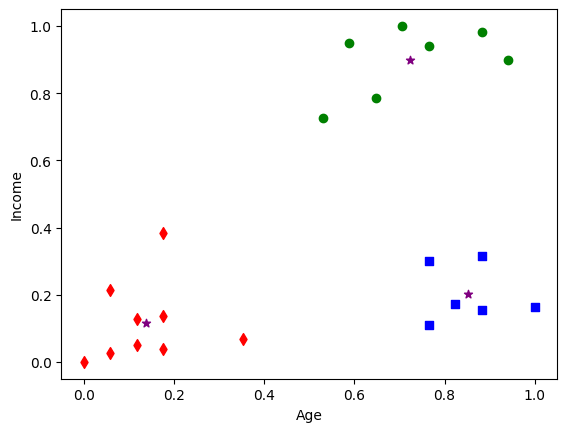

In [35]:
# Plot each cluster
plt.scatter(df1.Age, df1['Income($)'], color='green', marker='o')
plt.scatter(df2.Age, df2['Income($)'], color='red',  marker='d')
plt.scatter(df3.Age, df3['Income($)'], color='blue',  marker='s')

plt.scatter(x,y,color = 'purple' , marker = '*' , label = 'centroid')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()


In [36]:
see = []
k_range =  range(1,10)
for k in k_range:
    km = KMeans(n_clusters = k)
    km.fit_predict(df[['Age' ,'Income($)']])
    see.append(km.inertia_)   
    

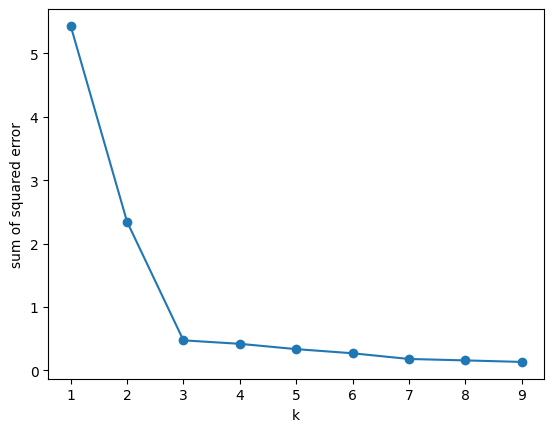

In [38]:
plt.plot(k_range, see, marker='o')
plt.xlabel('k')
plt.ylabel('sum of squared error')
plt.show()